In [2]:
from pathlib import Path
import pandas as pd 
import numpy as np
from tqdm.auto import tqdm
import plotly.express as px
from plotly import graph_objects as go
tqdm.pandas()

root = Path('/data/data/malpolon/xgb/')
inputs_path = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/')
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')

In [3]:
fulldf = pd.read_csv(inputs_path / 'database_common.csv', index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})
species = list(fulldf.columns[-818:-1])
groundtruth = fulldf[species]

In [4]:
# Checkpoints

mm_cp_pa = '26_hum_env_dhw_bathy_common_pa-2025-11-10_16-31'
td_cp_pa = '37_mm4_transductif-2025-12-02_12-47'

mm_cp_reg = '38_mm4_transductif_reg-2026-03-05_11-37'
td_cp_reg = '38_mm4_transductif_reg-2026-03-04_16-44'

mm_cp_eco = '40_mm4_transductif_eco-2026-03-02_14-58'
td_cp_eco = '40_mm4_transductif_eco-2026-03-02_14-03'

## P-A

#### Species F1

In [ ]:
xgb_f1 = pd.read_csv(next((root / 'pa').glob("xgbbest_f1*.csv")), index_col = 0)
mm_f1 = pd.read_csv(next((output_path / mm_cp_pa).glob("testF1*.csv")), index_col = 0)
td_f1 = pd.read_csv(next((output_path / td_cp_pa).glob("testF1*.csv")), index_col = 0)

In [ ]:
scores = pd.concat([xgb_f1["f1"], mm_f1["f1"], td_f1["f1"]], axis = 1)
names = ['XGBoost', 'Deep-SDM', 'Transductive']
scores.columns = names

y = []

for n in names:
    y1 = scores[[n]].sort_values(ascending=False, by=n)
    y1.reset_index(inplace=True)
    y1.columns = ['species', 'F1']
    y1['x'] = np.arange(len(y1))
    y1['model'] = n
    y.append(y1)

data = pd.concat(y)

In [18]:
import plotly.express as px

fig = px.line(data[data['x'] <= 400], x='x', y='F1', color='model', template = 'simple_white',
           width = 800, height=800,
           color_discrete_sequence = px.colors.qualitative.Pastel)

fig.update_layout(
    title='', #'Presence-absence classification',
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend_title_text='',
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)

fig.update_traces(line={'width': 4})

[Text(0.5, 0, 'XGBoost F1'), Text(0, 0.5, 'Transductive F1')]

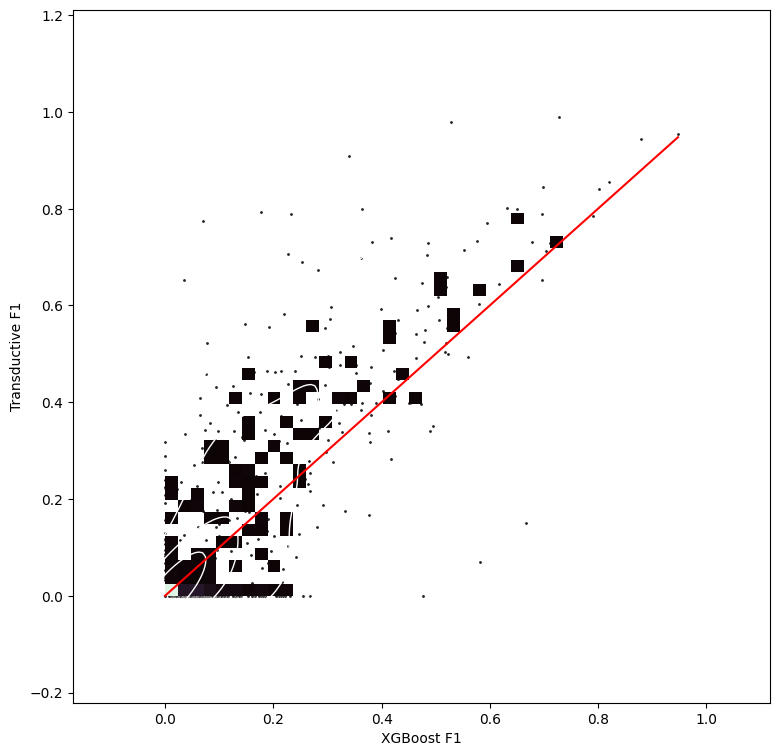

In [6]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores[names[0]].values, scores[names[2]].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel=names[0] + ' F1', ylabel=names[2] + ' F1')

#### Site F1

In [ ]:
xgb_f1_site = pd.read_csv(next((root / 'pa').glob("xgbbest_f1_by_site.csv")), index_col = 0)
td_f1_site = pd.read_csv(next((output_path / td_cp_pa).glob("f1_by_site_new.csv")), index_col = 0)

scores = pd.concat([xgb_f1_site['f1'], td_f1_site['f1']], axis=1)
scores.columns = ['XGB', 'TD']

In [10]:
import plotly.express as px

site_F1_improv = pd.DataFrame(xgbbest_f1)[['site', 'lat', 'lon']]
site_F1_improv['delta'] = (scores['TD'] - scores['XGB']) #/ (scores['XGB']+1e-6)

fig = px.scatter_map(site_F1_improv, lat='lat',lon='lon', color='delta', height = 1100, width = 1200,
                     center={'lat':-28, 'lon':133}, zoom=4, opacity=0.5,
                     color_continuous_midpoint=0,
                     color_continuous_scale=px.colors.sequential.RdBu, map_style='dark')

fig.update_traces(marker=dict(size=20))
fig.show()

In [11]:
(site_F1_improv['delta'] / (scores['XGB']+1e-6)).describe()

count    412.000000
mean       0.329958
std        0.495271
min       -0.999997
25%        0.081309
50%        0.275250
75%        0.553950
max        3.221229
dtype: float64

[Text(0.5, 0, 'XGB F1'), Text(0, 0.5, 'TD F1')]

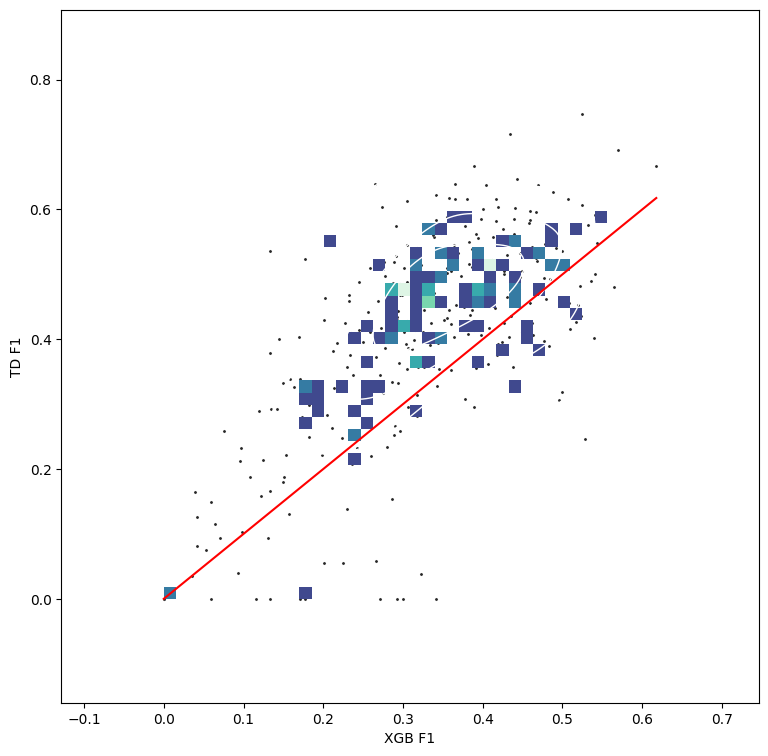

In [12]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores['XGB'].values, scores['TD'].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel='XGB F1', ylabel='TD F1')

## Reg

In [44]:
xgb_r2 = pd.read_csv(next((root / 'reg').glob("xgb_best_r2*.csv")), index_col = 0)
mm_r2 = pd.read_csv(next((output_path / mm_cp_reg).glob("testR2--*.csv")), index_col = 0)
td_r2 = pd.read_csv(next((output_path / td_cp_reg).glob("testR2--*.csv")), index_col = 0)

In [45]:
scores = pd.concat([xgb_r2["pearsonr_nz"], mm_r2["pearsonr_nz"], 
                    td_r2["pearsonr_nz"]], axis = 1)
names = ['XGBoost', 'Deep-SDM',
         'Transductive']
scores.columns = names

y = []

for n in names:
    y1 = scores[[n]].sort_values(ascending=False, by=n)
    y1.reset_index(inplace=True)
    y1.columns = ['species', 'pearsonr_nz']
    y1['x'] = np.arange(len(y1))
    y1['model'] = n
    y.append(y1)

data = pd.concat(y)

In [46]:
import plotly.express as px

fig = px.line(data[data['x'] <= 400], x='x', y='pearsonr_nz', color='model', template = 'simple_white',
           width = 800, height=800,
           color_discrete_sequence = px.colors.qualitative.Pastel)

fig.update_layout(
    title='', #'Biomass regression',
    xaxis_title='Species rank',
    yaxis_title='Pearson R',
    font=dict(size=20),
    legend_title_text='',
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)

fig.update_traces(line={'width': 4})


fig.update_layout(
    yaxis={'side': 'right'},
    #showlegend=False
)

In [16]:
scores['delta'] = (scores['Transductive'] - scores['XGBoost']) / (scores['XGBoost']+1e-6)
scores['delta'].describe()

count     782.000000
mean       -1.805902
std        93.219415
min     -1988.800826
25%        -0.469179
50%         0.327894
75%         1.761176
max      1516.739267
Name: delta, dtype: float64

## Traits based

#### Load traits

In [3]:
traits = pd.read_csv('/data/data/RLS/traits.csv', index_col=0)

troph_level_dict = {s: traits['Troph'].get(s, np.nan) for s in species}
troph_level = pd.Series(troph_level_dict, index = species, name = 'troph_level')

uicnL_status_dict = {s: traits['IUCN_inferred_Loiseau23'].get(s, 'No Status') for s in species}
uicnL_status = pd.Series(uicnL_status_dict, index = species, name = 'uicnL_status')
uicnL_threatened = pd.Series([(uicnL_status_dict[s] == 'Threatened')*1 for s in species], index = species, name = 'Threatened')

uicn_species = list(uicnL_threatened[uicnL_threatened == 1].index)

#### Load scores to compare

In [ ]:
# P-A

xgb_f1 = pd.read_csv(next((root / 'pa').glob("xgbbest_f1*.csv")), index_col = 0)
td_f1 = pd.read_csv(next((output_path / td_cp_pa).glob("testF1*.csv")), index_col = 0)

scores = pd.concat([xgb_f1["f1"], td_f1["f1"]], axis = 1)

In [ ]:
# Reg

xgb_r2 = pd.read_csv(next((root / 'reg').glob("xgb_best_r2*.csv")), index_col = 0)
td_r2 = pd.read_csv(next((output_path / td_cp_reg).glob("testR2--*.csv")), index_col = 0)

scores = pd.concat([xgb_r2["pearsonr"], td_r2["pearsonr"]], axis = 1)

In [5]:
# Calculate progress

names = ['XGB', 'Transductive']
scores.columns = names
scores['progress_perc'] = (scores[names[1]] - scores[names[0]]) / (scores[names[0]] + 1e-6)
scores['progress'] = (scores[names[1]] - scores[names[0]]) 
scores['max'] = scores[names].max(axis=1)


# Add traits
scores['uicnL_status'] = uicnL_status.loc[scores.index]
scores['troph_level'] = troph_level.loc[scores.index]

#### Plot performance increase vs traits

In [10]:
relevant_scores = scores.loc[scores['max'] > 0].copy()

fig = px.violin(relevant_scores, x="uicnL_status", y="progress", points = 'all', color = "uicnL_status",
                color_discrete_sequence= px.colors.qualitative.Pastel, box = True)


fig.update_layout(
    template='simple_white',
    width = 800, height=800,
    yaxis_title='Pearson delta',
    xaxis_title='',
    font=dict(size=20),
    showlegend=False)
    

fig.add_shape(type="line",
    xref="paper",
    x0=0, y0=0,
    x1=1, y1=0,
    line=dict(
        color="black",
        width=1,
    ))

fig.show()

In [8]:
relevant_scores = scores.loc[scores['max'] > 0].copy()

print(relevant_scores.groupby('uicnL_status')['progress_perc'].describe()['50%'])
print(relevant_scores['progress_perc'].describe()['50%'])

uicnL_status
No Status        -0.750912
Non Threatened    0.100303
Threatened        0.261194
Name: 50%, dtype: float64
0.06874256276621152


In [50]:
scores.sort_values(by='Transductive', ascending=False)

,XGB,Transductive,progress_perc,progress,max,uicnL_status,troph_level
Notolabrus gymnogenis,0.417212,0.651736,0.562119,0.234523,0.651736,Non Threatened,3.50
Chaetodon lunulatus,0.345173,0.534252,0.547780,0.189079,0.534252,Non Threatened,3.34
Halichoeres melanurus,0.361370,0.519718,0.438185,0.158348,0.519718,Non Threatened,2.90
Ophthalmolepis lineolatus,0.415375,0.518854,0.249121,0.103479,0.518854,Non Threatened,3.50
Ctenochaetus striatus,0.466384,0.507201,0.087519,0.040817,0.507201,Non Threatened,2.00
...,...,...,...,...,...,...,...
Pomacanthus navarchus,-0.100000,NaN,NaN,NaN,-0.100000,Non Threatened,2.66
Pseudocaranx sp. [dentex],-0.100000,NaN,NaN,NaN,-0.100000,No Status,NaN
Scorpaena cardinalis,-0.100000,NaN,NaN,NaN,-0.100000,Non Threatened,3.52
Stanulus talboti,-0.100000,NaN,NaN,NaN,-0.100000,Non Threatened,2.00


## Eco indicators

In [5]:
xgb_eco_r2 = pd.read_csv(next((root / 'eco').glob("xgb_best_r2*.csv")), index_col = 0)
mm_r2_eco = pd.read_csv(next((output_path / mm_cp_eco).glob("testR2--*.csv")), index_col = 0)
td_r2_eco = pd.read_csv(next((output_path / td_cp_eco).glob("testR2--*.csv")), index_col = 0)

tdstacked_r2 = pd.read_csv(output_path / td_cp_pa / 'eco_indic_corr.csv', index_col=0)

In [6]:
scores = pd.concat([xgb_eco_r2["pearsonr"], mm_r2_eco["pearsonr"], td_r2_eco["pearsonr"], tdstacked_r2["pearsonr"]], axis = 1)
names = ['XGBoost', 'Deep-SDM', 'Transductive (direct)', 'Transductive (computed)']
scores.columns = names

y = []

for n in names:
    y1 = scores[[n]].sort_values(ascending=False, by=n)
    y1.reset_index(inplace=True)
    y1.columns = ['species', 'pearsonr']
    y1['x'] = np.arange(len(y1))
    y1['model'] = n
    y.append(y1)

data = pd.concat(y)

In [7]:
import plotly.express as px

fig = px.bar(data, x=data['species'], y='pearsonr', color='model', template = 'simple_white', barmode='group',
           width = 800, height=800,
           color_discrete_sequence = px.colors.qualitative.Pastel)

fig.update_layout(
    title='Ecological indicators regression',
    xaxis_title='',
    yaxis_title='Pearson R',
    font=dict(size=20),
    legend_title_text='',
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)


## Any 2

#### 1v1 BlandAltman

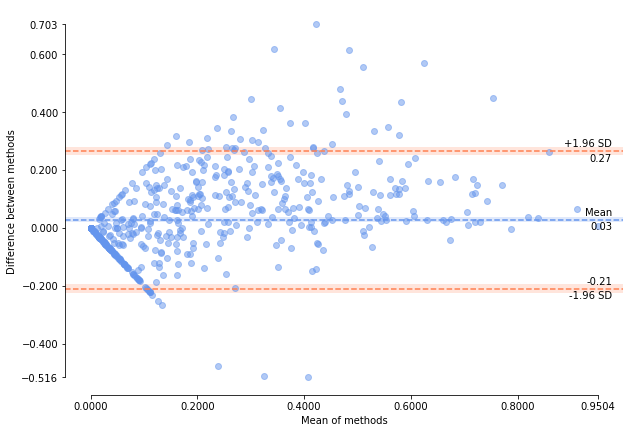

In [31]:
import pyCompare

pyCompare.blandAltman(scores[names[2]].values,scores[names[0]].values)

#### 1v1 Scatter plot

[Text(0.5, 0, 'XGBoost F1'), Text(0, 0.5, 'Transductive F1')]

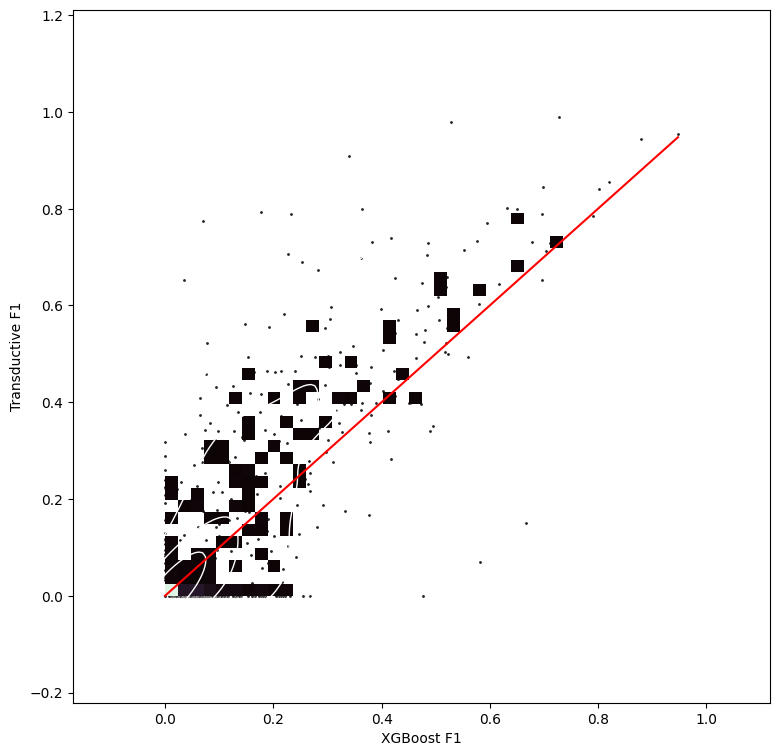

In [30]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores[names[0]].values, scores[names[2]].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel=names[0] + ' F1', ylabel=names[2] + ' F1')

#### 1v1 arrow scatter

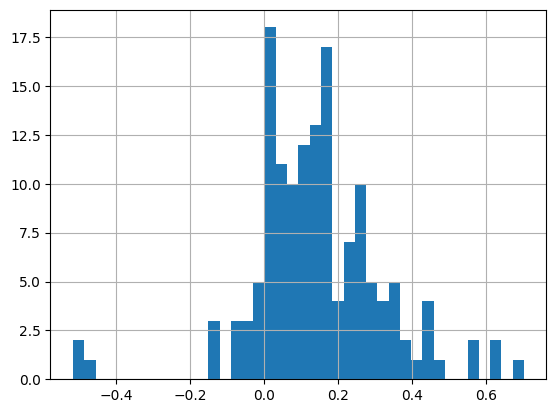

In [42]:
(relevant_scores['Transductive'] - relevant_scores['XGB']).hist(bins=40)

relevant_scores.sort_values(by='XGB', ascending=False, inplace=True)
relevant_scores['x'] = np.arange(len(relevant_scores))

In [45]:
# Example data
x = relevant_scores['x']
y1 = relevant_scores['XGB']
y2 = relevant_scores['Transductive']
hover_text = relevant_scores.index.to_list()

# Create the figure
fig = go.Figure()

# Add the two series as scatter plots
fig.add_trace(go.Scatter(
    x=x, y=y1,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[0], size=10),
    name='XGBoost',
    hovertext=hover_text,
    hoverinfo='text'
))

fig.add_trace(go.Scatter(
    x=x, y=y2,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[3], size=10),
    name='Transductive',
    hovertext=hover_text,
    hoverinfo='text'
))

# Add arrows for the differences
for i in range(len(x)):
    fig.add_annotation(
        ax=x[i], ay=y1[i],
        axref='x', ayref='y',
        x=x[i], y=y2[i],
        xref='x', yref='y',
        showarrow=True,
        arrowhead=1,
        arrowsize=1.5,
        arrowcolor=px.colors.qualitative.Pastel1[1],
        arrowwidth=1.5,
    )


fig.update_layout(
    template='simple_white',
    width = 1200, height=800,
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)


/tmp/ipykernel_6923/759123879.py:32: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_6923/759123879.py:34: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

